<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_C/Exp%208%20-%20OpenML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🌐 **Introduction to OpenML**

**OpenML** (Open Machine Learning) is a free and collaborative platform designed for sharing machine learning datasets, models, and experiments.  
It provides an extensive collection of benchmark datasets that can be easily accessed via Python using the `openml` library.

**Why OpenML?**
- 📚 Provides **thousands of datasets** for machine learning and data science.  
- ⚙️ Offers **easy integration** with popular libraries such as `scikit-learn` and `pandas`.  
- 💡 Supports **reproducible research** by allowing users to share and track their experiments.  
- 🔗 Each dataset has a **unique ID**, making it simple to load specific datasets directly into code.

In this project, we use the **Pima Indians Diabetes dataset (OpenML ID: 37)** — a medical dataset commonly used for binary classification.  
Our goal is to train a **Random Forest Classifier** to predict whether a patient is likely to have diabetes based on various medical features.

### 🧩 **Importing and Installing Libraries**

In this step, we first install the `openml` library, which allows us to fetch datasets directly from the OpenML platform.  
We then import the essential Python libraries:

- **openml** → to access and load datasets from the OpenML repository.  
- **pandas** → for data manipulation and analysis.  
- **matplotlib.pyplot** and **seaborn** → for data visualization and graphical representation.  
- **train_test_split** → to divide the dataset into training and testing subsets.  
- **RandomForestClassifier** → to train our predictive model.  
- **classification_report**, **confusion_matrix**, **accuracy_score** → for model performance evaluation.

These imports set up our environment for end-to-end machine learning workflow — from loading data to evaluating results.

In [ ]:
!pip install openml -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 34.1 MB/s eta 0:00:00


In [ ]:
import openml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 📥 **Loading the Breast Cancer (Wisconsin) Dataset**

We load the Breast Cancer Wisconsin dataset (OpenML ID: 15) using the openml.datasets.get_dataset() function.
This dataset is a binary classification problem used to predict whether a breast tumor is benign or malignant based on cytological features observed in cell samples.

It contains 699 samples, each described by 9 numeric features, including:



*  Clump thickness

*   Uniformity of cell size

*   Uniformity of cell shape

*   Marginal adhesion

*   Single epithelial cell size
*   Bare nuclei


*   Bland chromatin

*   Normal nucleoli

*  Mitoses




















The target variable (y) indicates the class of the tumor:

**benign** → Non-cancerous

**malignant** → Cancerous

After loading:

X holds the input features (cell characteristics).

y holds the target labels (benign/malignant).

We print the shape of X to view the number of samples and features.

We also examine the target distribution to ensure that both benign and malignant classes are properly represented in the dataset.

In [ ]:
dataset = openml.datasets.get_dataset(15)
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)

In [ ]:
print("✅ Dataset loaded successfully!")
print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")


✅ Dataset loaded successfully!
Features shape: (699, 9)
Target distribution:
Class
benign       458
malignant    241
Name: count, dtype: int64


### ✂️ **Splitting the Dataset into Training and Testing Sets**

To evaluate our model’s generalization ability, we split the data into two parts:

- **80% training data** → used to train the model.  
- **20% testing data** → used to test model performance on unseen data.

We use `train_test_split()` from scikit-learn with parameters:
- `test_size=0.2` → 20% for testing.  
- `random_state=42` → ensures reproducibility.  
- `stratify=y` → maintains the same class ratio in both training and test sets.

This step ensures that our model is trained on one portion of the dataset and evaluated on another, preventing overfitting.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 🌲 **Training the Random Forest Model**

Here we initialize and train a **Random Forest Classifier** — an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

- `n_estimators=100` → builds 100 decision trees.  
- `random_state=42` → ensures consistent results each time the code runs.

We train the model using `model.fit(X_train, y_train)`, which allows it to learn patterns and relationships between the features and the target variable.


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

### 🎯 **Making Predictions on the Test Set**

After training, the model is used to predict outcomes on the unseen **test data (`X_test`)** using the `.predict()` method.  
The predicted labels are stored in `y_pred`.

These predictions will later be compared to the actual labels (`y_test`) to measure how accurate and reliable our model is.

In [ ]:
y_pred = model.predict(X_test)

### 📊 **Generating and Interpreting the Classification Report**

The **classification report** provides a detailed summary of the model’s performance across each class.  
It includes key metrics such as:

- **Precision** → fraction of correctly predicted positive instances among all predicted positives.  
- **Recall (Sensitivity)** → fraction of correctly predicted positive instances among all actual positives.  
- **F1-Score** → harmonic mean of precision and recall, balancing both metrics.  
- **Support** → number of true instances for each class in the dataset.

We convert the report to a pandas DataFrame for better visualization and readability.  
This report helps us identify if the model performs equally well on both diabetic and non-diabetic classes.

In [ ]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print("\n📊 Classification Report:")
print(report_df)



📊 Classification Report:
              precision    recall  f1-score     support
benign         0.988764  0.956522  0.972376   92.000000
malignant      0.921569  0.979167  0.949495   48.000000
accuracy       0.964286  0.964286  0.964286    0.964286
macro avg      0.955166  0.967844  0.960935  140.000000
weighted avg   0.965726  0.964286  0.964531  140.000000


### 🧮 **Visualizing the Confusion Matrix**

The **confusion matrix** helps visualize how well the classifier performs by showing the count of correct and incorrect predictions for each class.

- The **rows** represent the true class labels.  
- The **columns** represent the predicted class labels.  
- The **diagonal elements** represent correctly predicted instances.  
- The **off-diagonal elements** represent misclassifications.

We use `seaborn.heatmap()` to plot the matrix with annotations for better clarity.  
This visualization quickly shows which class labels the model struggles to predict correctly.

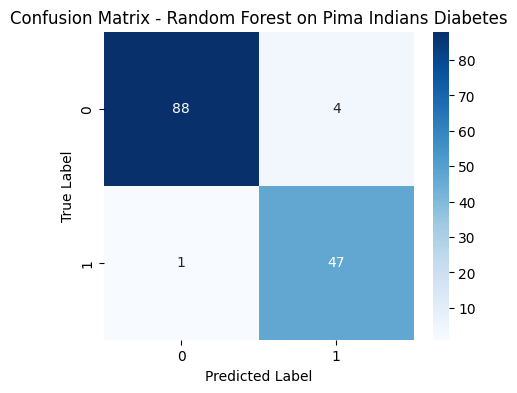

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest on Pima Indians Diabetes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 🎯 **Calculating the Model’s Accuracy**

Finally, we calculate the model’s overall **accuracy** using the `accuracy_score()` function.  
Accuracy measures the proportion of correctly predicted samples out of the total test samples.

The formula is:
\[
Accuracy = \frac{\text{Number of Correct Predictions}}{\text{Total Predictions}} \times 100
\]

This gives a quick and intuitive measure of how well the Random Forest model performs on the Pima Indians Diabetes dataset.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Model Accuracy: {accuracy*100:.2f}%")


🎯 Model Accuracy: 96.43%
